# Agglomerative (Hierarchical) Clustering

## Table of Contents

### 1. What is Agglomerative Clustering?

### 2. Agglomerative Clustering in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for Agglomerative Clustering

## 1. What is Agglomerative Clustering?

A hierarchical clustering method that builds a tree (dendrogram) of clusters.

“Agglomerative” means bottom-up:

- Start with each point as its own cluster

- Iteratively merge the two closest clusters

- Repeat until all points are merged into one cluster or a desired number of clusters is reached

Result: a dendrogram (tree diagram showing cluster merges)

Goal: Understand **hierarchical relationships** between data points.

**Unlike K-Means, it does not require random initialization, so results are deterministic given the same parameters**


## 2. Agglomerative Clustering in Scikit-Learn

The name of the class for Agglomerative Clustering in Scikit-Learn
  **sklearn.cluster.AgglomerativeClustering**


## **AgglomerativeClustering Parameters Explained (scikit-learn)**

### **Most Important Parameters**

### `1. n_clusters`
-  The number of clusters to form. Determines how many groups the algorithm will merge the points into.  
- default=2
- If you also set `distance_threshold`, this parameter is ignored because merging is stopped based on distance rather than cluster count.  

### `2.metric`

Distance metric used to calculate similarity between points. Determines which points are “close” to each other.

**Common Options:**  
  - `euclidean` (default) → straight-line distance; most common for numeric features.  
  - `manhattan` → sum of absolute differences; robust to outliers.  
  - `cosine` → measures angle between vectors; useful for text embeddings   

### `3. linkage`

Determines how the distance between **clusters** is computed during merging  

**Options**  

  - `ward` (default) → merges clusters that **minimize the variance** of combined cluster; produces compact, round clusters. Only works with Euclidean distance

  - `complete` → distance = **maximum distance** between any two points across clusters. Produces **tight, well-separated clusters**

  - `average` → distance = **average of all pairwise distances** between points in the two clusters. Balanced behavior between single and complete linkage

Different linkages affect **cluster shape, size and sensitivity to noise**  




**Important rules and constraints:**
- If `linkage="ward"`, **only `"euclidean"` is allowed**  
  (because Ward’s method relies on variance minimization).

Choice of metric affects which points are considered “close” and thus which clusters are merged first  


### **Occasionally Used Parameters**

### `distance_threshold`

Stops merging clusters when the distance between clusters exceeds this threshold.

**Options:** float (default=None)  

- Useful when you want a **hierarchy** and do not know the number of clusters in advance

- Example: `distance_threshold=5` → any clusters separated by more than 5 units will **not merge**, creating more clusters automatically

- If set, `n_clusters` is ignored  


### `compute_full_tree`

Determines whether the full clustering tree is computed. Needed for dendrogram plotting.  

**Options**  (default=auto)
  - `auto` → computes full tree only when needed (e.g., small datasets or dendrogram)
  - `True` → always compute the full tree; useful for plotting dendrograms  
  - `False` → skips computing full tree to save memory and computation for large datasets

### Apply Agglomerative Clustering to a simple Dataset

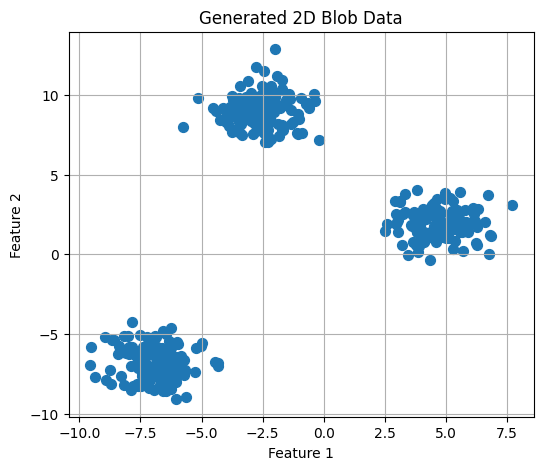

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from sklearn.metrics import silhouette_score

# Generate 400 points in 2D, 3 clusters
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the raw data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

Silhouette Score: 0.8458787585795497


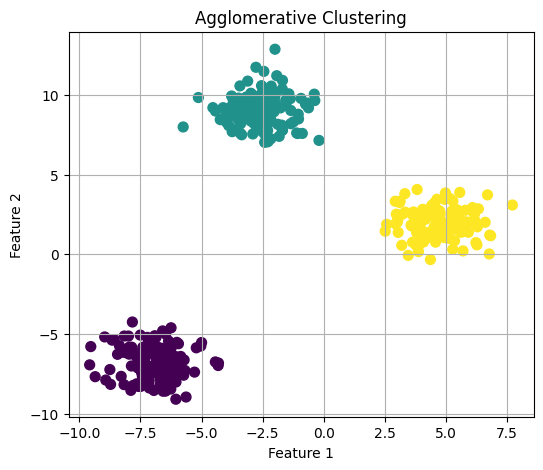

In [24]:
# Create the model
agg = AgglomerativeClustering(
    n_clusters=3,       # we know 3 clusters exist
    metric='euclidean',  # distance metric
    linkage='ward'          # linkage method
)

# Fit and predict cluster labels
labels = agg.fit_predict(X)
score = silhouette_score(X, labels)
print("Silhouette Score:", score)
# Plot clustered data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Clustering")
plt.grid(True)
plt.show()

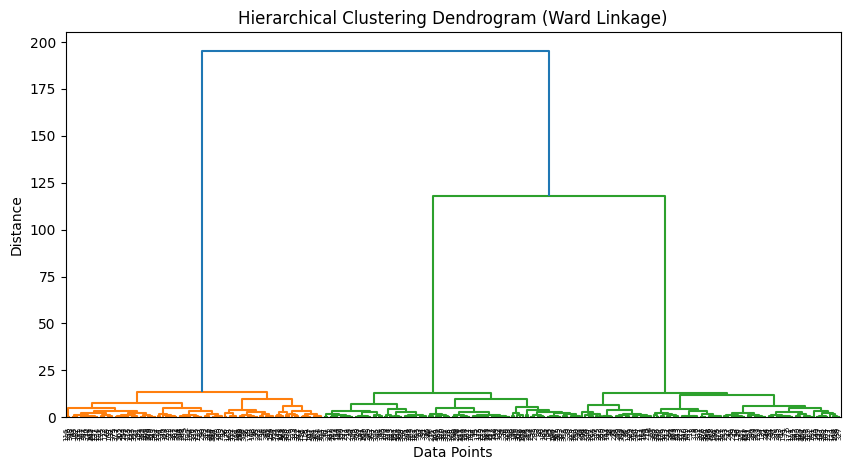

In [25]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

#### How to Interpret the Dendrogram

- Each leaf → one data point

- Each merge → two clusters being combined

- The height of a merge → distance between clusters

#### Choosing the Number of Clusters

- Draw a horizontal line across the dendrogram

- Count how many vertical branches it cuts

### Rule of thumb:

Choose the cut where there is a large vertical gap
(big jump in distance before clusters merge)

## Important Considerations for Agglomerative Clustering

### When to Use Agglomerative Clustering

**- Does not require specifying K upfront:**  
Hierarchical clustering can build a full hierarchy of clusters and allows you to decide the number of clusters later by cutting the dendrogram at a chosen level.

**- Works well with small to medium datasets:**  
Because it computes distances between many pairs of points, it is more suitable when the dataset is not extremely large.

**- Useful for understanding data structure:**  
The dendrogram provides a visual explanation of how data points are grouped, making it useful for exploratory analysis.

**- Flexible cluster shapes (linkage):**  
Different linkage methods allow the algorithm to capture different types of cluster structures


### Limitations of Agglomerative Clustering

**- Computationally expensive:**  
Agglomerative clustering has higher time and memory complexity, making it impractical for very large datasets

**- Sensitive to noise and outliers:**  
Outliers can form their own clusters or distort the merging process

**- Early decisions cannot be undone:**  
Once two clusters are merged, the algorithm cannot reconsider that decision later, which may lead to suboptimal clusters

**- Results depend heavily on linkage choice:**  
Different linkage methods can produce very different clusterings, so parameter selection is critical

## Task 2A: Agglomerative Clustering

In this task, you will apply **Agglomerative Clustering** to `CC GENERAL` dataset and follow **the same methodology** used in the previous clustering lab

## **1. Exploratory Data Analysis (EDA)**

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

df = pd.read_csv("CC GENERAL.csv")
df.head()


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [27]:
print("Shape:", df.shape)
print("\n--- Info ---")
df.info()
print("\n--- Describe ---")
df.describe()


Shape: (8950, 18)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  895

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [28]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nMissing value percentages:")
print((df.isnull().sum() / len(df) * 100).round(2))


Missing values per column:
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Missing value percentages:
CUST_ID                             0.00
BALANCE                             0.00
BALANCE_FREQUENCY                   0.00
PURCHASES                           0.00
ONEOFF_PURCHASES                    0.00
INSTALL

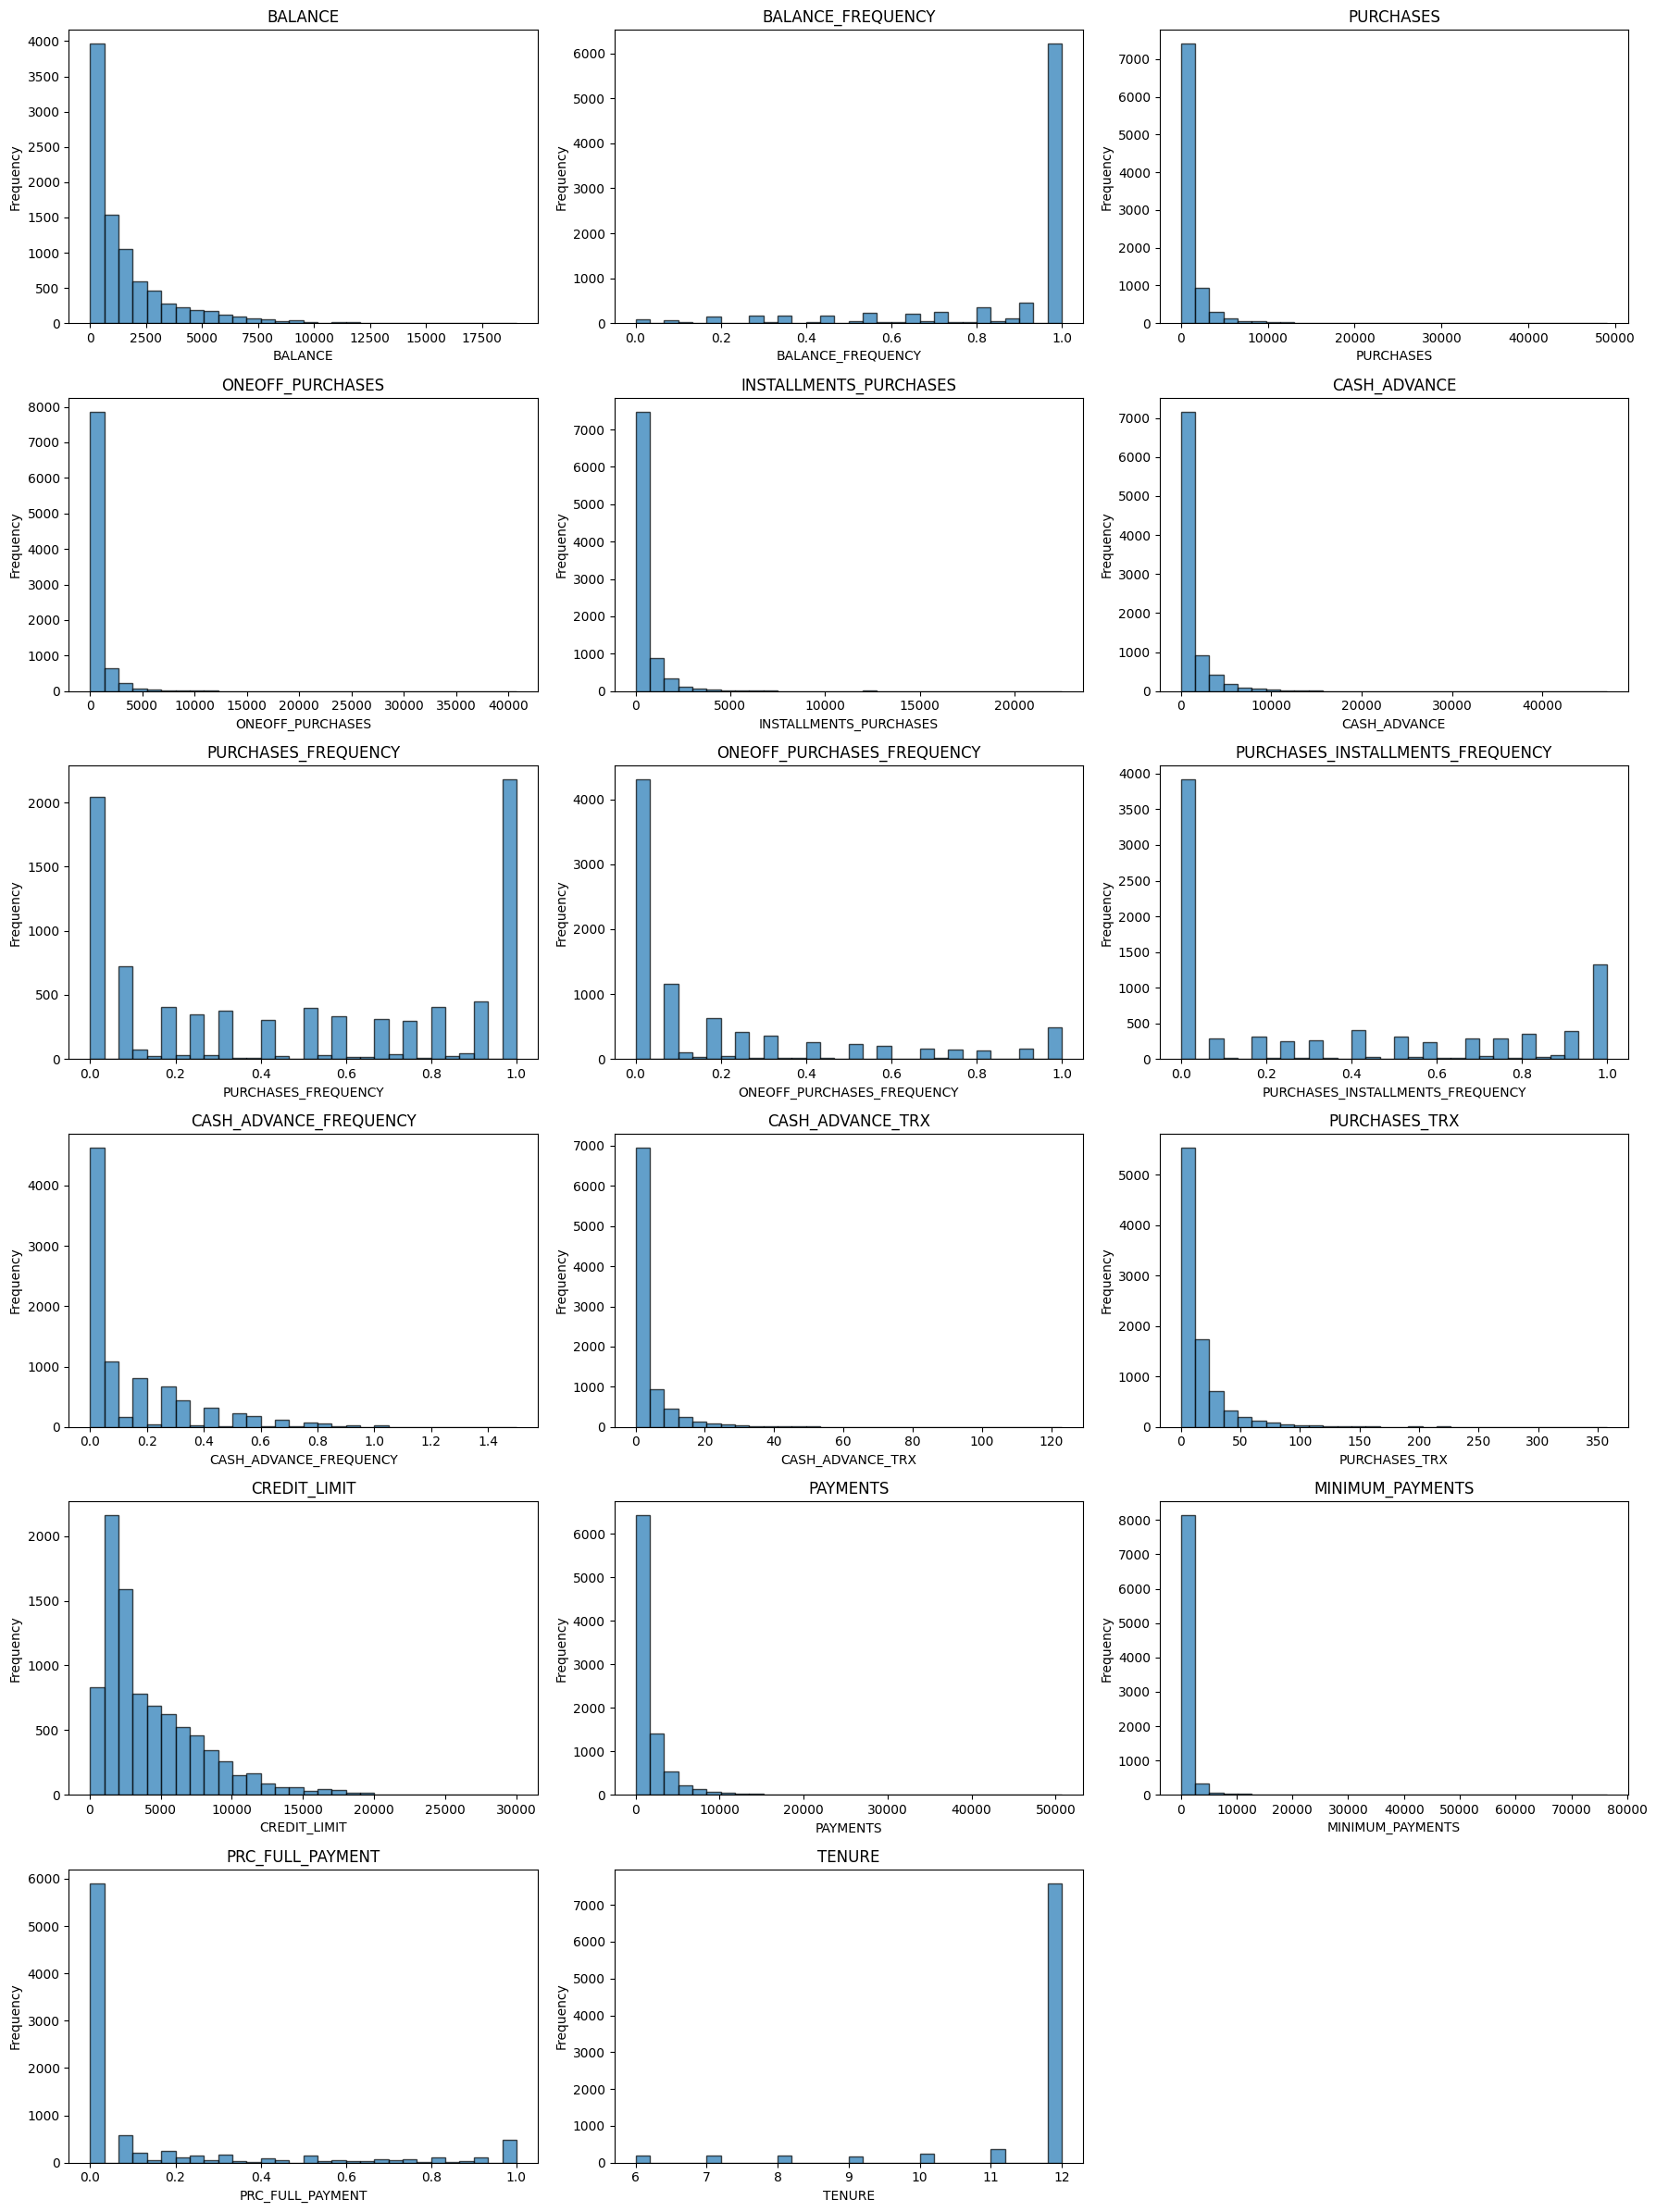

In [29]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(nrows=len(numeric_cols) // 3 + 1, ncols=3, figsize=(18, 4 * (len(numeric_cols) // 3 + 1)))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

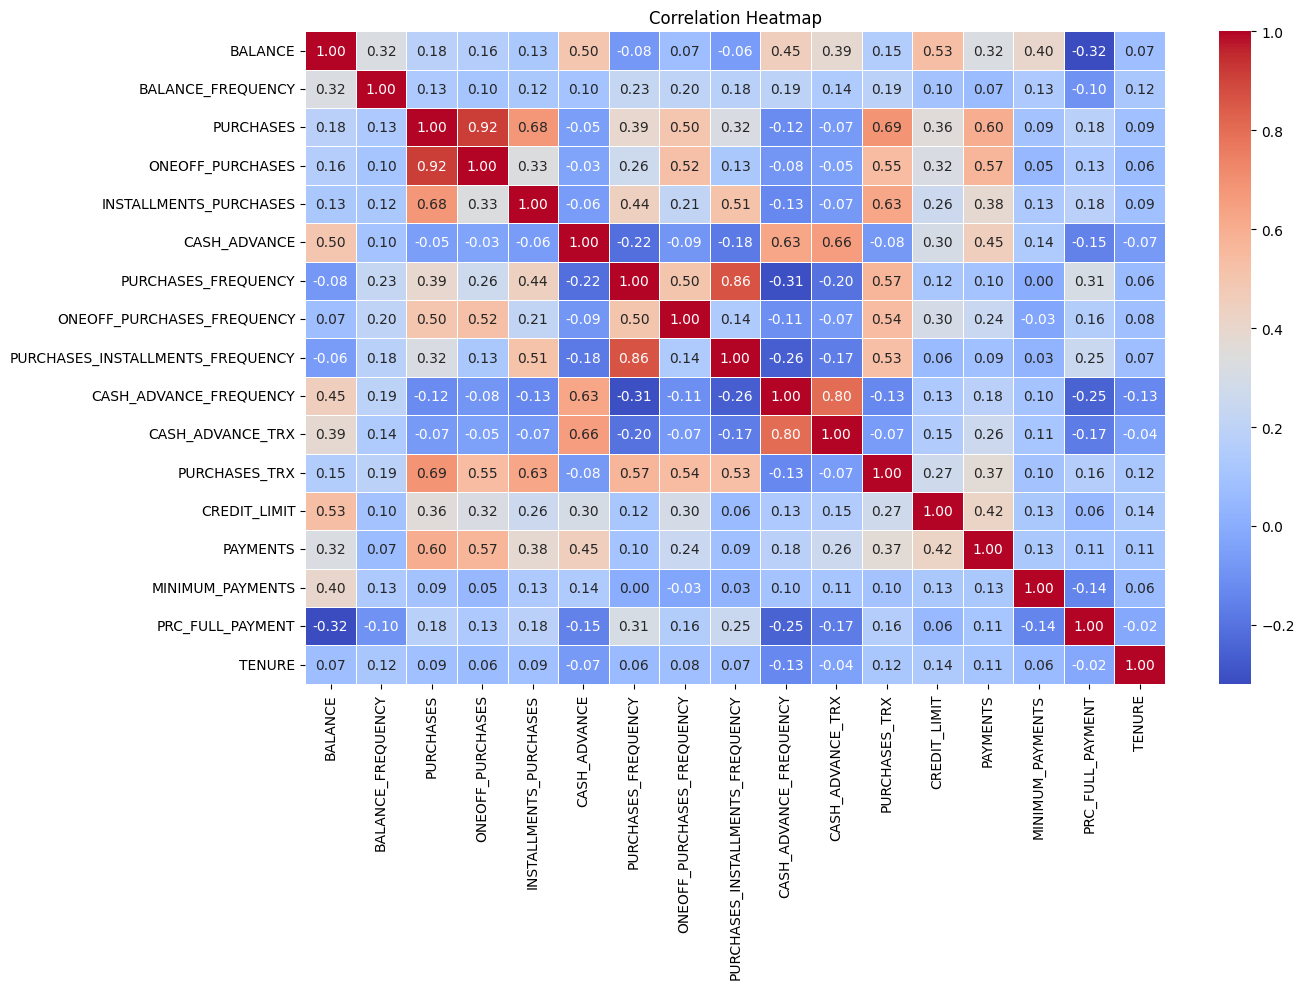

In [30]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## **2. Data Preparation**

In [31]:
df_clean = df.drop(columns=["CUST_ID"])
print("Columns after dropping CUST_ID:", df_clean.columns.tolist())


Columns after dropping CUST_ID: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


In [32]:
print("Missing before fill:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

df_clean.fillna(df_clean.median(), inplace=True)

print("\nMissing after fill:")
print(df_clean.isnull().sum().sum())


Missing before fill:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Missing after fill:
0


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)
print("Scaled data shape:", X_scaled.shape)



Scaled data shape: (8950, 17)


In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("PCA data shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", sum(pca.explained_variance_ratio_))


PCA data shape: (8950, 2)
Explained variance ratio: [0.27297671 0.2031378 ]
Total explained variance: 0.4761145096128464


## **3. Apply Agglomerative Clustering**

In [ ]:
agg = AgglomerativeClustering(
    n_clusters=4,
    metric='euclidean',
    linkage='ward'
)
labels = agg.fit_predict(X_scaled)
print("Cluster labels:", np.unique(labels))
print("Cluster distribution:")
print(pd.Series(labels).value_counts().sort_index())


Cluster labels: [0 1 2 3]
Cluster distribution:
0    4875
1     300
2    1194
3    2581
Name: count, dtype: int64


In [ ]:
silhouette_scores = {}
K_range = range(2, 9)

for k in K_range:
    agg_k = AgglomerativeClustering(
        n_clusters=k,
        metric='euclidean',
        linkage='ward'
    )
    labels_k = agg_k.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_k)
    silhouette_scores[k] = score
    print(f"k={k} -> Silhouette Score: {score:.4f}")


k=2 -> Silhouette Score: 0.1921
k=3 -> Silhouette Score: 0.1674
k=4 -> Silhouette Score: 0.1598
k=5 -> Silhouette Score: 0.1763
k=6 -> Silhouette Score: 0.1593
k=7 -> Silhouette Score: 0.1617


KeyboardInterrupt: 

In [ ]:
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nBest k = {best_k} with Silhouette Score = {silhouette_scores[best_k]:.4f}")



Best k = 2 with Silhouette Score = 0.1921


In [ ]:
agg_final = AgglomerativeClustering(
    n_clusters=best_k,
    metric='euclidean',
    linkage='ward'
)
final_labels = agg_final.fit_predict(X_scaled)
print(f"\nFinal clustering with k={best_k}:")
print(pd.Series(final_labels).value_counts().sort_index())




Final clustering with k=2:
0    6069
1    2881
Name: count, dtype: int64


## **4. Visualize the Clustering Results**

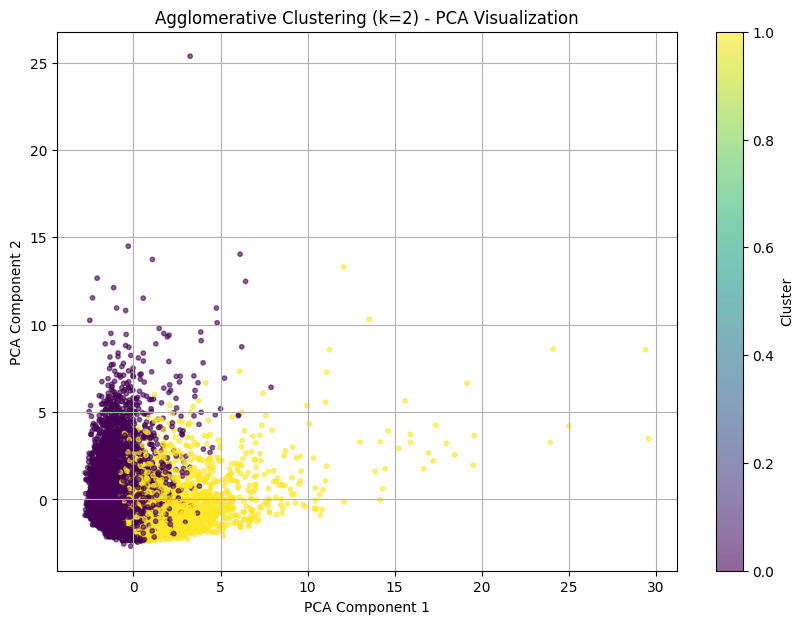

In [ ]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, cmap='viridis', s=10, alpha=0.6)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"Agglomerative Clustering (k={best_k}) - PCA Visualization")
plt.grid(True)
plt.show()


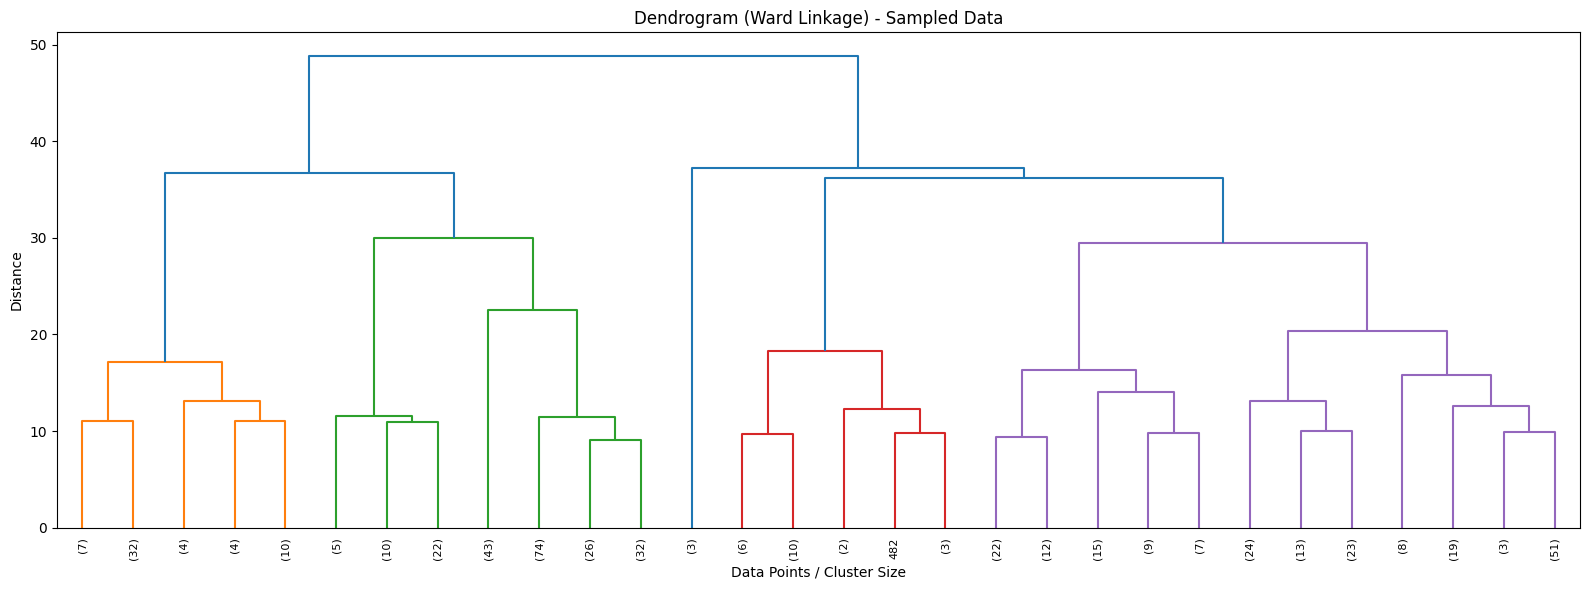

In [ ]:
sample_size = min(500, len(X_scaled))
np.random.seed(42)
sample_indices = np.random.choice(len(X_scaled), size=sample_size, replace=False)
X_sample = X_scaled[sample_indices]

Z = linkage(X_sample, method='ward', metric='euclidean')

plt.figure(figsize=(16, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=8)
plt.title("Dendrogram (Ward Linkage) - Sampled Data")
plt.xlabel("Data Points / Cluster Size")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()



In [ ]:
df_clustered = df_clean.copy()
df_clustered['Cluster'] = final_labels

cluster_means = df_clustered.groupby('Cluster').mean()
print("Cluster Centers (Feature Means):")
cluster_means


Cluster Centers (Feature Means):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1653.861262,0.834041,407.246187,279.474220,128.034951,1232.928852,0.291090,0.130452,0.165666,0.165775,3.952875,5.465810,4096.621945,1434.617983,903.815699,0.087254,11.309277
1,1376.176922,0.968336,2258.627612,1251.713096,1007.293058,443.683185,0.910106,0.354142,0.783160,0.070618,1.765706,34.182923,5331.978322,2362.006573,720.811553,0.293717,11.955571


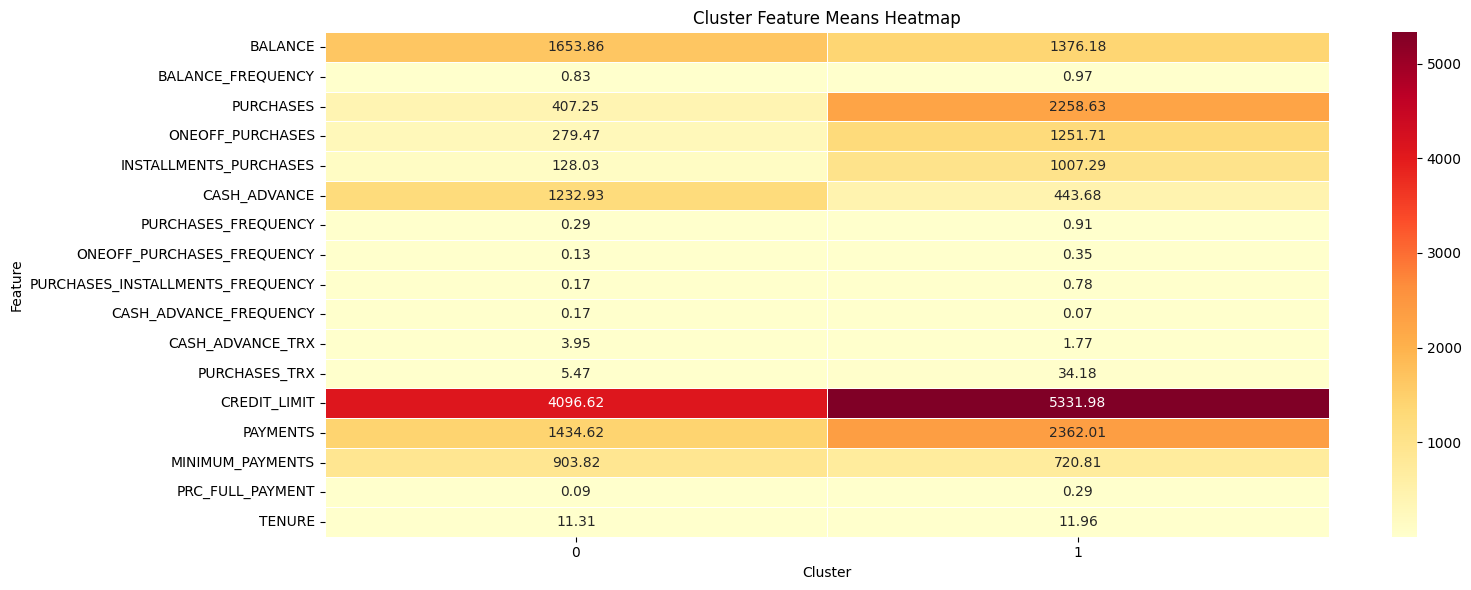

In [ ]:
plt.figure(figsize=(16, 6))
sns.heatmap(cluster_means.T, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Cluster Feature Means Heatmap")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## **5. Evaluate the Clustering**

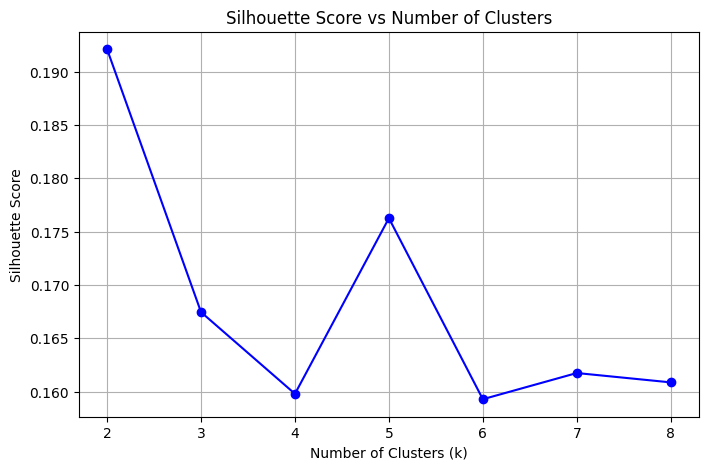

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), 'bo-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.grid(True)
plt.xticks(list(K_range))
plt.show()

In [ ]:
final_score = silhouette_score(X_scaled, final_labels)
print(f"Final Model Silhouette Score (k={best_k}): {final_score:.4f}")


Final Model Silhouette Score (k=2): 0.1921


In [ ]:
linkage_methods = ['ward', 'complete', 'average']

for method in linkage_methods:
    if method == 'ward':
        agg_link = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage=method)
    else:
        agg_link = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage=method)
    labels_link = agg_link.fit_predict(X_scaled)
    score_link = silhouette_score(X_scaled, labels_link)
    print(f"Linkage: {method:10s} -> Silhouette Score: {score_link:.4f}")


Linkage: ward       -> Silhouette Score: 0.1921
Linkage: complete   -> Silhouette Score: 0.7866
Linkage: average    -> Silhouette Score: 0.8408


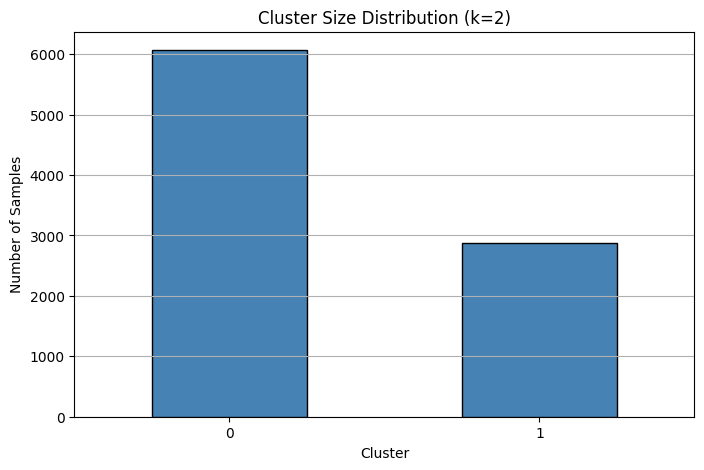

In [ ]:
plt.figure(figsize=(8, 5))
cluster_counts = pd.Series(final_labels).value_counts().sort_index()
cluster_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title(f"Cluster Size Distribution (k={best_k})")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


## **6. Explain whether the clustering quality and justify your reasoning**

In [ ]:
CLUSTERING QUALITY EXPLANATION:

The ward linkage silhouette score was 0.1921 at k=2, which is low but expected for 
real-world financial data with 17 features — customer behavior has a lot of overlap 
and high dimensionality makes distance-based clustering less effective.

Complete (0.7866) and average (0.8408) linkage scored much higher, but those scores 
are misleading — they likely just isolated outliers into tiny clusters while dumping 
most data into one big group. Ward gives more balanced, interpretable results.

The k=2 split still makes business sense: Cluster 0 is cash-advance-heavy users 
(avg ~1233) with low purchases (~407), while Cluster 1 is active purchasers (~2259) 
with higher credit limits and payment frequency. The dendrogram supports this — the 
biggest distance gap is at the top where the two main branches split.

Overall the clustering isn't strong numerically, but it captures a meaningful 
behavioral difference. PCA before clustering or DBSCAN could improve results.